In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [136]:
df=pd.read_csv('Diwali_Sales_Data.csv',encoding='unicode-escape')

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [138]:
df=df.drop(columns=['Status','unnamed1'])

In [139]:
nd_amt=df['Amount'].median()

In [140]:
df['Amount']=df['Amount'].fillna(nd_amt)

In [141]:
df['Amount']=df['Amount'].astype(int)

# DATA VISULIAZATION

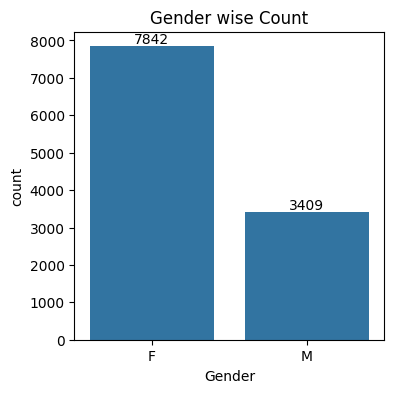

In [142]:
plt.figure(figsize=(4,4))
ax=sn.countplot(data=df,x='Gender')
plt.title('Gender wise Count')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [143]:
amount=df.groupby('Gender').agg({'Amount':'sum'})

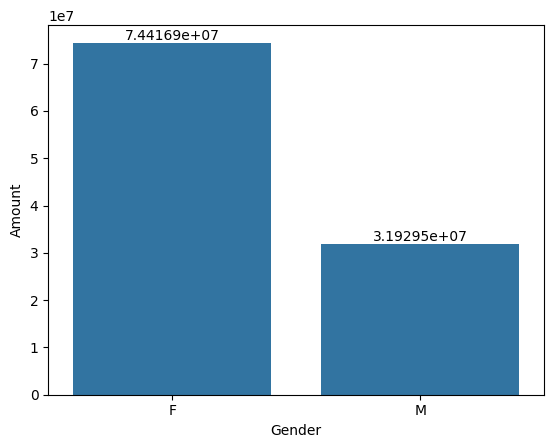

In [144]:

ax=sn.barplot(data=amount,x='Gender',y='Amount')
for bars in ax.containers:
    ax.bar_label(bars)

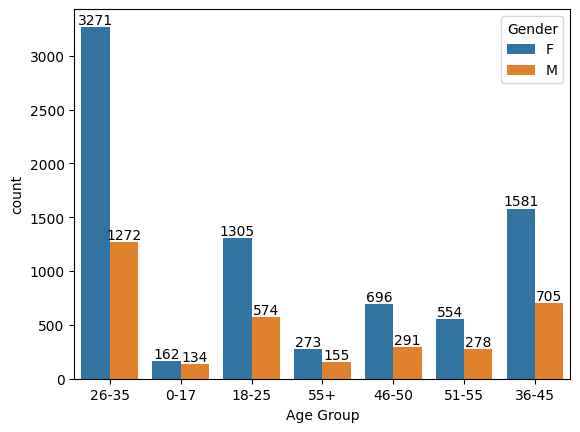

In [145]:
ax=sn.countplot(data=df,x='Age Group',hue='Gender')
for bars in ax.containers:
    ax.bar_label(bars)


In [155]:
age_amount=df.groupby('Age Group').agg({'Amount':'sum'})

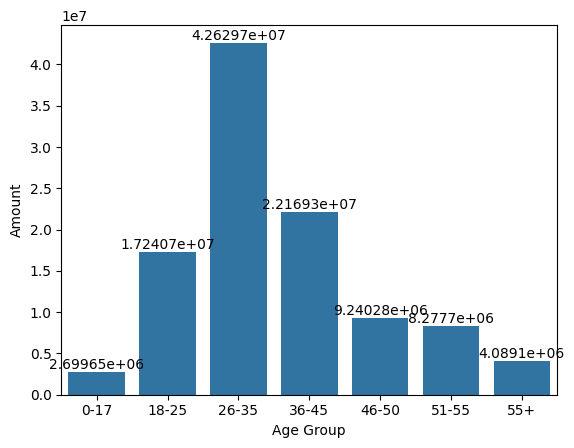

In [157]:
ax=sn.barplot(data=age_amount,x='Age Group',y='Amount')
for bars in ax.containers:
    ax.bar_label(bars)

In [158]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [177]:
state=df.groupby('State').agg({'Orders':'sum'}).sort_values(by='Orders',ascending=False)

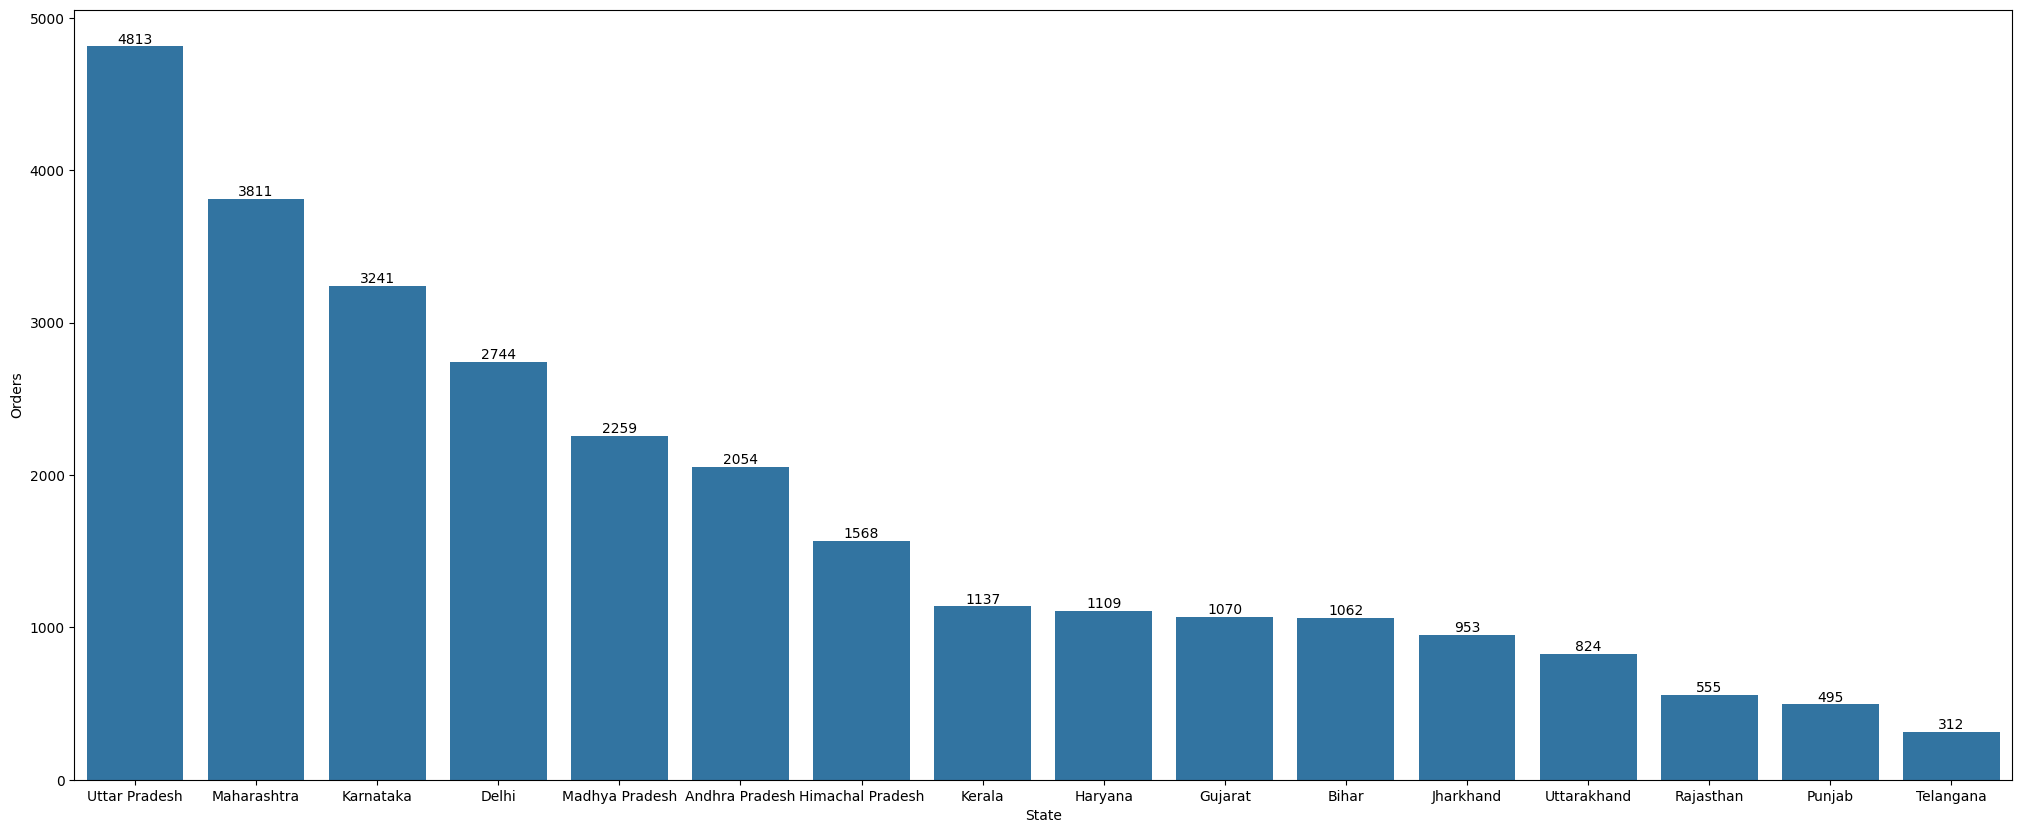

In [178]:
plt.figure(figsize=(25,10))
ax=sn.barplot(data=state,x='State',y='Orders')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [183]:
stateamt=df.groupby('State').agg({'Amount':'sum'}).sort_values(by='Amount',ascending=False).head(10)

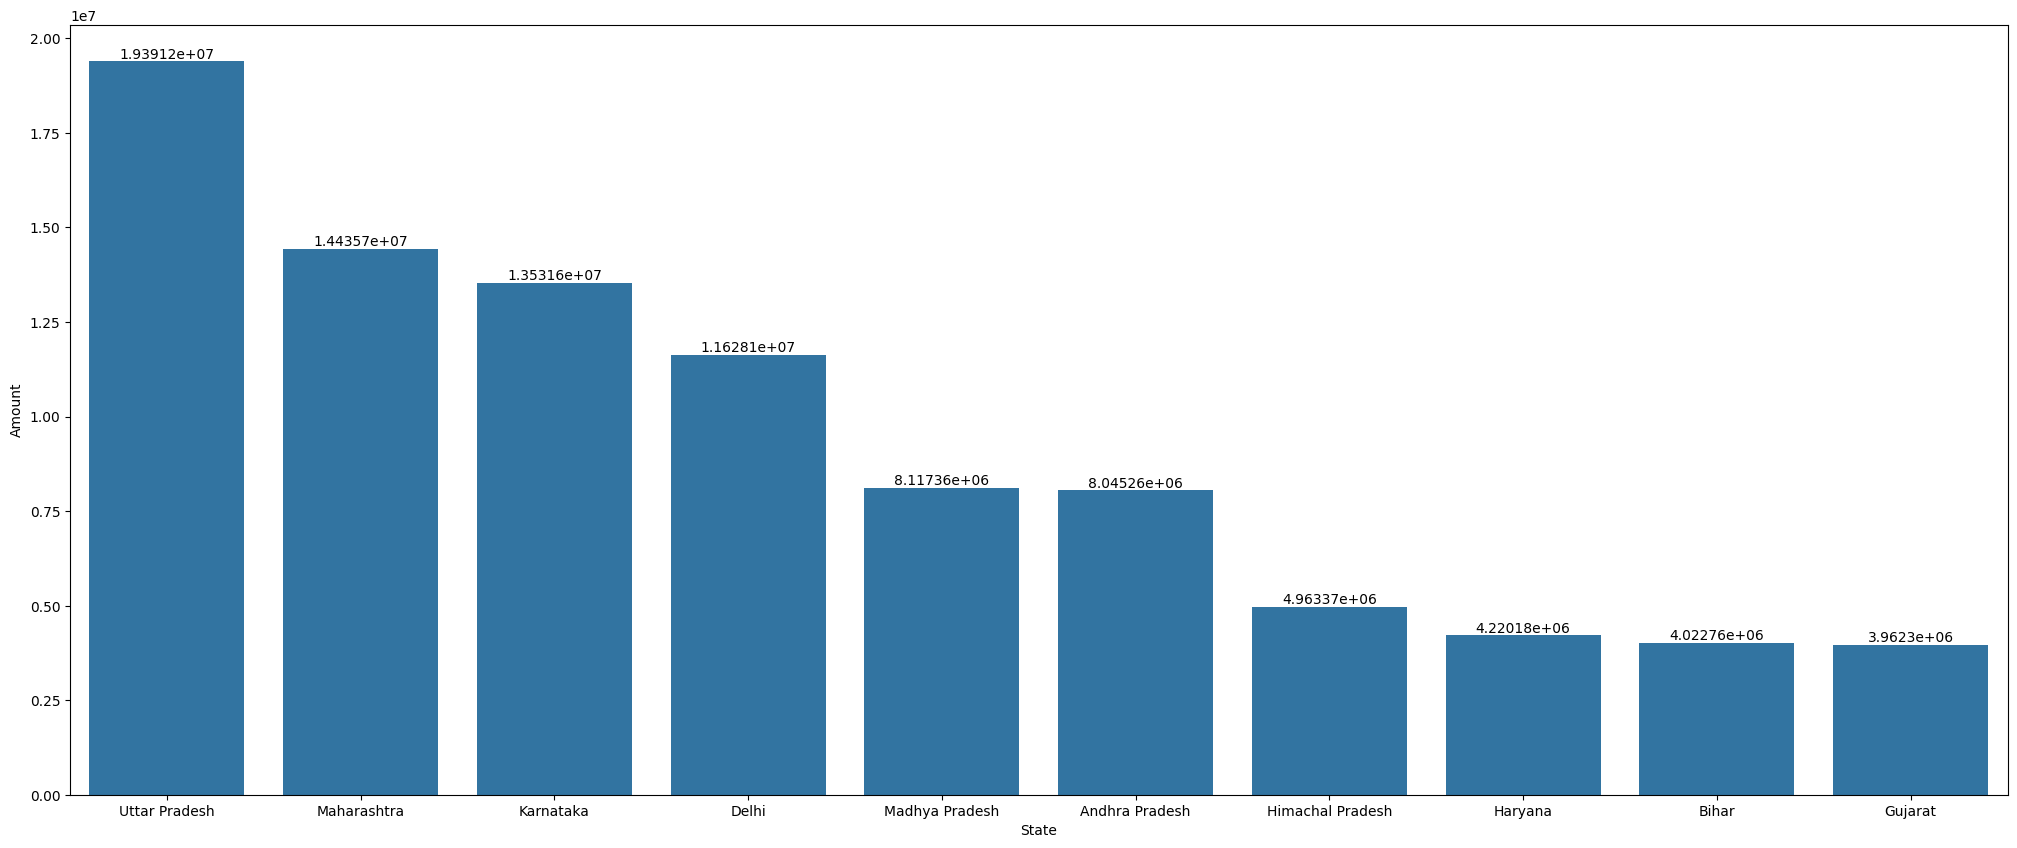

In [184]:
plt.figure(figsize=(25,10))
ax=sn.barplot(data=stateamt,x='State',y='Amount')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

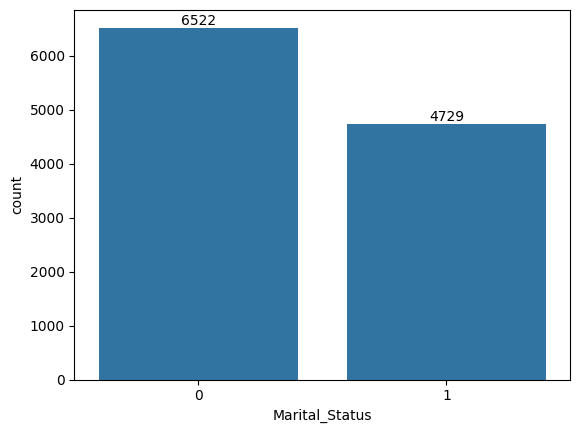

In [ ]:
ax=sn.countplot(data=df,x='Marital_Status')
for bars in ax.containers:
    ax.bar_label(bars) 

<Axes: xlabel='Marital_Status', ylabel='Amount'>

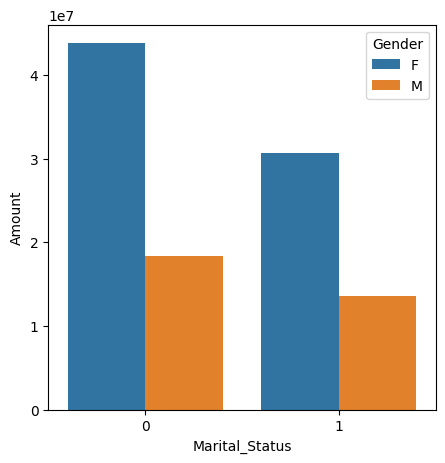

In [199]:
plt.figure(figsize=(5,5))
status=df.groupby(['Marital_Status','Gender']).agg({'Amount':'sum'})
sn.barplot(data=status,x='Marital_Status',y='Amount',hue='Gender')

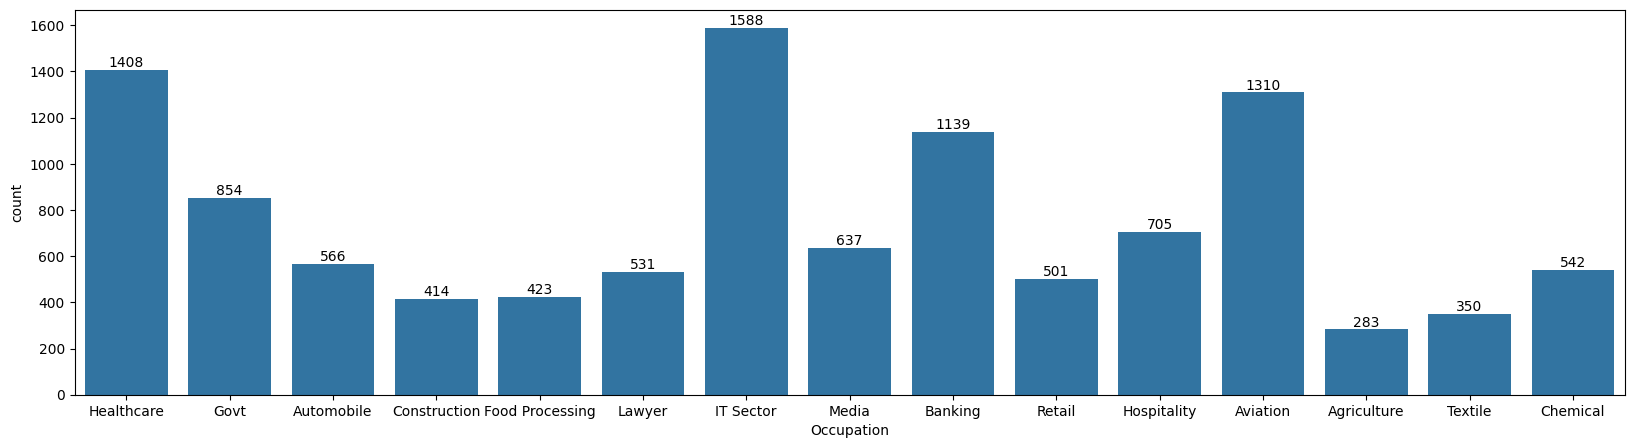

In [202]:
plt.figure(figsize=(20,5))
ax=sn.countplot(data=df,x='Occupation')
for bars in ax.containers:
    ax.bar_label(bars)

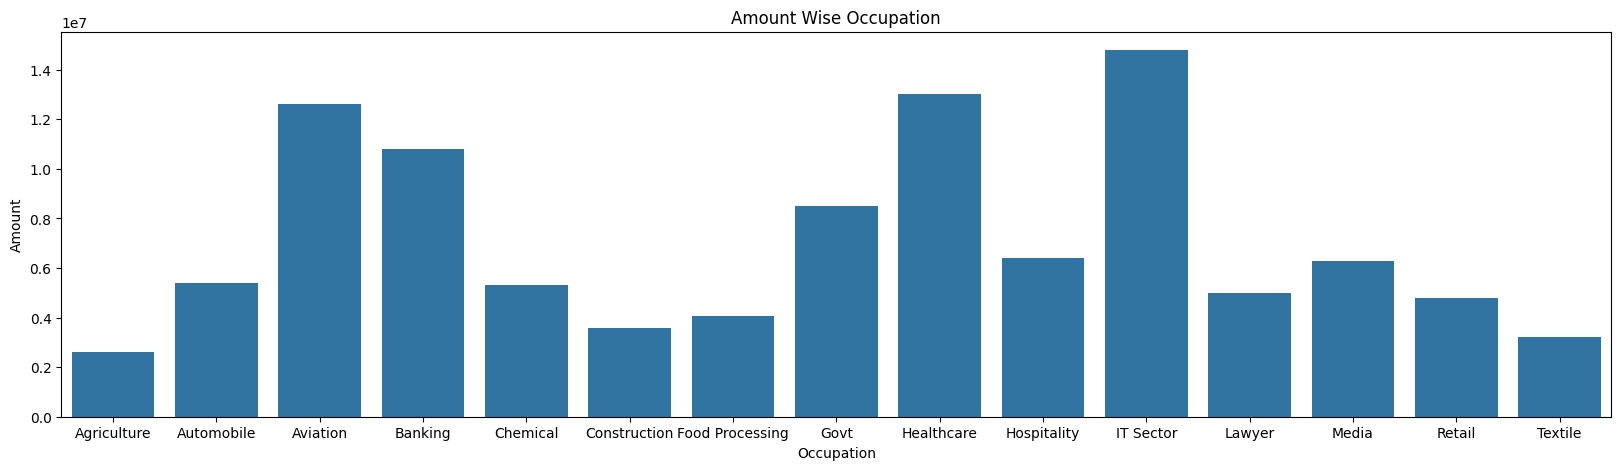

In [210]:
plt.figure(figsize=(20,5))
occ=df.groupby('Occupation').agg({'Amount':'sum'})
sn.barplot(data=occ,x='Occupation',y='Amount')
plt.title('Amount Wise Occupation')
plt.show()

In [211]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

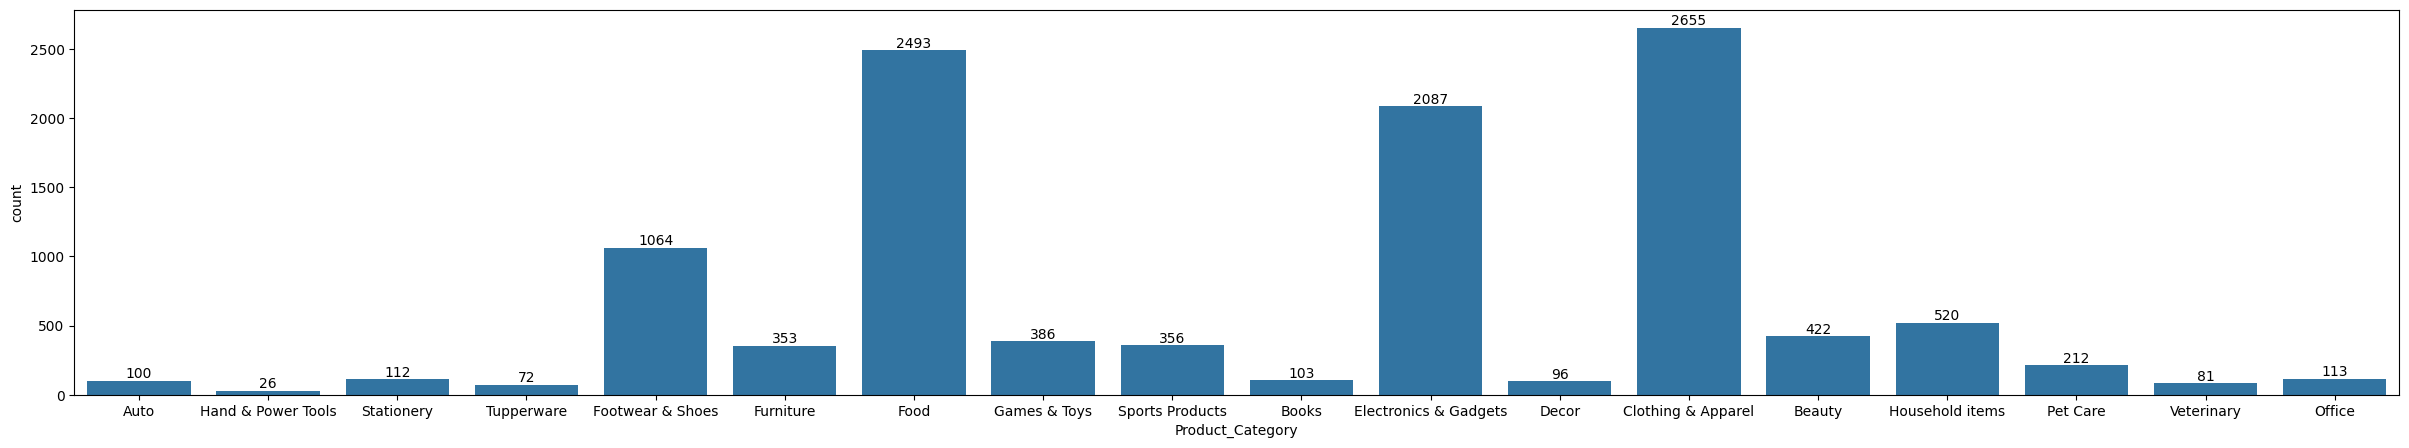

In [217]:
plt.figure(figsize=(30,5))
ax=sn.countplot(data=df,x='Product_Category')
for bars in ax.containers:
    ax.bar_label(bars)

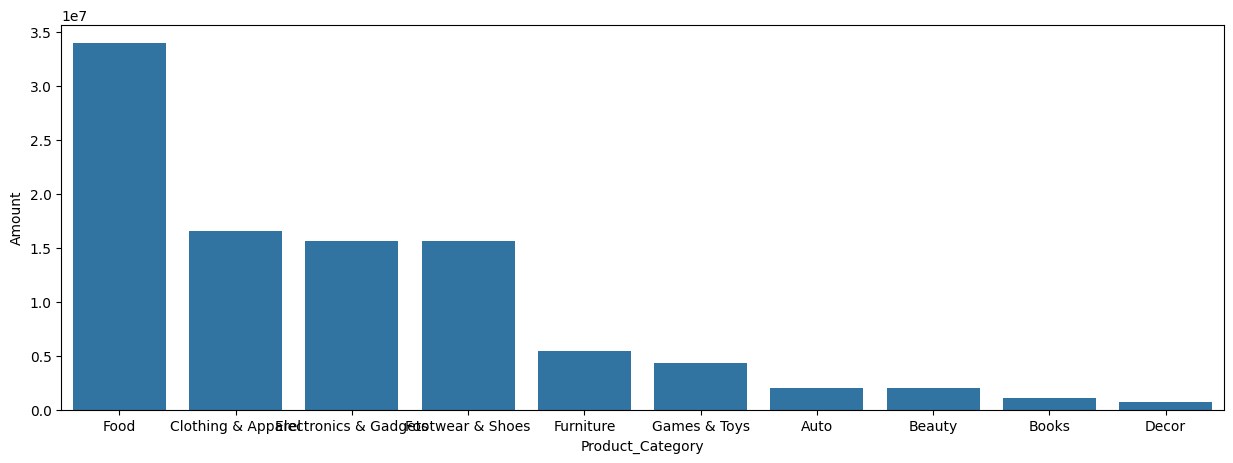

In [229]:
plt.figure(figsize=(15,5))
product=df.groupby('Product_Category').agg({'Amount':'sum'}).head(10).sort_values(by='Amount',ascending=False)
sn.barplot(data=product,x='Product_Category',y='Amount')
plt.show()